### Digit Recognizer

#### Overview

MNIST ("Modified National Institute of Standards and Technology") is the de facto “hello world” dataset of computer vision. Since its release in 1999, this classic dataset of handwritten images has served as the basis for benchmarking classification algorithms. As new machine learning techniques emerge, MNIST remains a reliable resource for researchers and learners alike.

In this competition, your goal is to correctly identify digits from a dataset of tens of thousands of handwritten images. We’ve curated a set of tutorial-style kernels which cover everything from regression to neural networks. We encourage you to experiment with different algorithms to learn first-hand what works well and how techniques compare.

https://www.kaggle.com/competitions/digit-recognizer

#### Data Description

The data files train.csv and test.csv contain gray-scale images of hand-drawn digits, from zero through nine.

Each image is 28 pixels in height and 28 pixels in width, for a total of 784 pixels in total. Each pixel has a single pixel-value associated with it, indicating the lightness or darkness of that pixel, with higher numbers meaning darker. This pixel-value is an integer between 0 and 255, inclusive.

The training data set, (train.csv), has 785 columns. The first column, called "label", is the digit that was drawn by the user. The rest of the columns contain the pixel-values of the associated image.

Each pixel column in the training set has a name like pixelx, where x is an integer between 0 and 783, inclusive. To locate this pixel on the image, suppose that we have decomposed x as x = i * 28 + j, where i and j are integers between 0 and 27, inclusive. Then pixelx is located on row i and column j of a 28 x 28 matrix, (indexing by zero).

For example, pixel31 indicates the pixel that is in the fourth column from the left, and the second row from the top, as in the ascii-diagram below.

Visually, if we omit the "pixel" prefix, the pixels make up the image like this:

```
000 001 002 003 ... 026 027
028 029 030 031 ... 054 055
056 057 058 059 ... 082 083
 |   |   |   |  ...  |   |
728 729 730 731 ... 754 755
756 757 758 759 ... 782 783 
The test data set, (test.csv), is the same as the training set, except that it does not contain the "label" column.
```

Your submission file should be in the following format: For each of the 28000 images in the test set, output a single line containing the ImageId and the digit you predict. For example, if you predict that the first image is of a 3, the second image is of a 7, and the third image is of a 8, then your submission file would look like:

```
ImageId,Label
1,3
2,7
3,8 
(27997 more lines)
```

The evaluation metric for this contest is the categorization accuracy, or the proportion of test images that are correctly classified. For example, a categorization accuracy of 0.97 indicates that you have correctly classified all but 3% of the images.

#### Notbook Structure

1. Exploratory Data Analysis
2. Data Processing
3. Modeling & Evaluation
4. Error Analysis
5. Hyperparameter Optimization
6. Kaggle Submission

### Setup

#### Install Packages

In [41]:
%%time
%pip install pandas numpy matplotlib optuna scikit-learn
%pip install torch==2.8.0+cpu torchvision==0.23.0+cpu torchaudio==2.8.0+cpu \
    --index-url https://download.pytorch.org/whl/cpu

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.
CPU times: total: 15.6 ms
Wall time: 2.24 s



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Import Packages

In [42]:
import os
from pathlib import Path
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate
import random
from sklearn.metrics import ConfusionMatrixDisplay

import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import ConcatDataset
from torch.utils.data import random_split
from torch.utils.data import Dataset

import optuna
import torch
import torch.nn as nn
import torch.optim as optim

#### Download the Data

In [43]:
data_path = Path() / ".." / "data"
submission_path = Path() / ".." / "submissions"

competition_name = "Digit Recognizer"

print(f'digit_data_path: {data_path}')
print(f'digit_submission_path: {submission_path}')

digit_data_path: ..\data
digit_submission_path: ..\submissions


In [44]:
# Read the data
def load_digit_data(filename, data_path=data_path):
    csv_path = os.path.join(data_path, filename)
    return pd.read_csv(csv_path)

# Save submission file

def save_submission(df, filename, submission_path=submission_path, competition_name=competition_name):
  if not os.path.exists(submission_path):
    os.makedirs(submission_path)

  timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
  name, ext = os.path.splitext(filename)
  new_filename = f"{name}_{competition_name.replace(' ', '_')}_{timestamp}{ext}"
  csv_path = os.path.join(submission_path, new_filename)

  return df.to_csv(csv_path, index=False)

In [45]:
train_data = load_digit_data("train.csv")
test_data = load_digit_data("test.csv")

print(f"Train data type: {type(train_data)}")
print(f"Test data type: {type(test_data)}")
print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

display(train_data.head(2))


Train data type: <class 'pandas.DataFrame'>
Test data type: <class 'pandas.DataFrame'>
Train data shape: (42000, 785)
Test data shape: (28000, 784)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


* Each row in train_data represents one image.
* The first column (label) is the digit (0–9).
* The next 784 columns (pixel0 to pixel783) are grayscale pixel values (0–255).
* To reshape a row of pixel values into a 28x28 image:
    * For pixel column pixelx, compute i=floor(x/28) (row), j=x%28 (column).
    * The pixel value is at position (i,j) in the image.

### 1. Exploratory Data Analysis

In [46]:
# Check for missing data in train_data
missing_counts = train_data.isnull().sum()
total_missing = missing_counts.sum()

if total_missing == 0:
    print("No missing data found in train_data.")
else:
    print("Missing data found in train_data:")
    print(missing_counts[missing_counts > 0])

No missing data found in train_data.


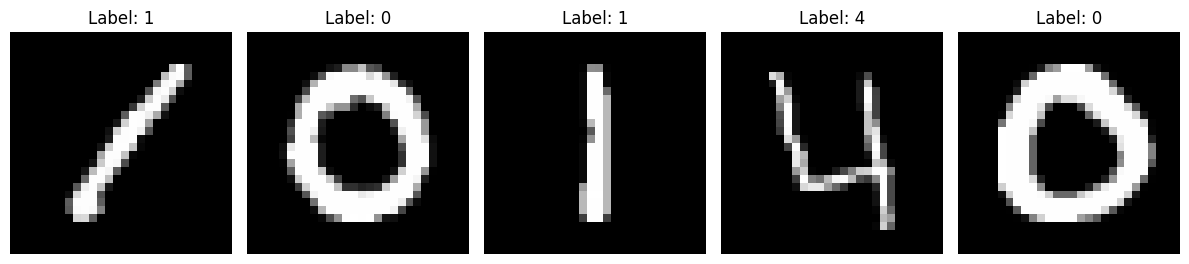

In [47]:
# Reshape the first 5 images for visualization
# Get pixel columns in the correct order using column names
pixel_columns = [col for col in train_data.columns if col.startswith('pixel')]
pixel_columns_sorted = sorted(pixel_columns, key=lambda x: int(x.replace('pixel', '')))

# Extract and reshape the first 5 images using the sorted pixel columns
images_5_ordered = train_data[pixel_columns_sorted].iloc[:5].values.reshape(-1, 28, 28)
labels_5 = train_data['label'].iloc[:5].values

# Plot the first 5 images with their labels (using ordered pixels)
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(images_5_ordered[i], cmap='gray')
    ax.set_title(f"Label: {labels_5[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()



Performs light image augmentation by rotating each image and concatenating the original and rotated images into a new augmented training set.

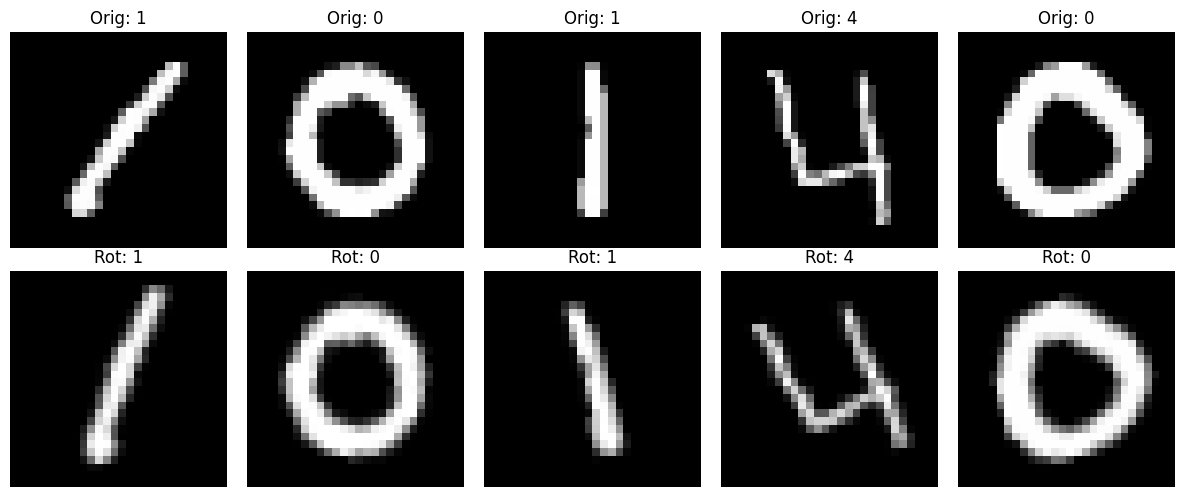

In [48]:
# Augment images by rotating each image by a small angle (e.g., 10 degrees)
angle = 15

# Extract pixel values as numpy array
X = train_data[pixel_columns_sorted].values
y = train_data['label'].values

# Reshape to (num_samples, 28, 28)
X_images = X.reshape(-1, 28, 28)

# Rotate each image
angles = np.random.choice([15, -15], size=len(X_images))
X_rotated = np.array([rotate(img, ang, reshape=False, order=1, mode='nearest') for img, ang in zip(X_images, angles)])

# Flatten rotated images back to (num_samples, 784)
X_rotated_flat = X_rotated.reshape(-1, 784)

# Create DataFrames for original and augmented data
df_original = train_data.copy()
df_augmented = pd.DataFrame(X_rotated_flat, columns=pixel_columns_sorted)
df_augmented['label'] = y

# Concatenate original and augmented data
train_data_augmented = pd.concat([df_original, df_augmented], ignore_index=True)

# Show first 5 original and augmented images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    # Original
    axes[0, i].imshow(X_images[i], cmap='gray')
    axes[0, i].set_title(f"Orig: {y[i]}")
    axes[0, i].axis('off')
    # Augmented
    axes[1, i].imshow(X_rotated[i], cmap='gray')
    axes[1, i].set_title(f"Rot: {y[i]}")
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

### 2. Data Processing

##### Dataset Class

In [77]:
class MNISTDataset(Dataset):
    def __init__(self, dataframe, pixel_cols, transform=None, has_labels=True):
        self.X = dataframe[pixel_cols].values.reshape(-1, 28, 28).astype(np.uint8)
        self.transform = transform
        self.has_labels = has_labels

        if has_labels:
            self.y = dataframe['label'].values.astype(np.int64)
        else:
            self.y = None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]

        if self.transform:
            image = self.transform(image)

        if self.has_labels:
            label = self.y[idx]
            return image, label
        else:
            return image

##### Transforms Function

In [50]:
def get_transforms(aug=False):
    normalize = transforms.Normalize((0.1307,), (0.3081,))

    train_transforms = []

    train_transforms.append(transforms.ToPILImage())
    if aug:
        train_transforms.append(transforms.RandomRotation(15))
    train_transforms.append(transforms.ToTensor())
    train_transforms.append(normalize)

    train_transform = transforms.Compose(train_transforms)

    val_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.ToTensor(),
        normalize
    ])

    return train_transform, val_transform

##### Dataloaders Function

In [51]:
def get_dataloaders(train_df, val_df, pixel_cols, aug=False, batch_size=64):
    train_tf, val_tf = get_transforms(aug)

    train_ds = MNISTDataset(train_df, pixel_cols, transform=train_tf)
    val_ds = MNISTDataset(val_df, pixel_cols, transform=val_tf)

    print(f"type(train_ds): {type(train_ds)}")
    print(f"type(val_ds): {type(val_ds)}")
    print(f"train_ds size: {len(train_ds)}")
    print(f"val_ds size: {len(val_ds)}")

    train_loader = DataLoader(train_ds, 
                                batch_size=batch_size, 
                                shuffle=True,
                                pin_memory=True
                                )
    val_loader = DataLoader(val_ds, 
                                batch_size=batch_size, 
                                shuffle=False,
                                pin_memory=True
                                )   

    return train_loader, val_loader

##### Train / Validation Split

In [52]:
# reproducibility
seed = 42
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# shuffle indices
indices = np.random.permutation(len(train_data))
train_size = int(0.8 * len(train_data))

# split dataframes
train_df = train_data.iloc[indices[:train_size]].reset_index(drop=True)
val_df   = train_data.iloc[indices[train_size:]].reset_index(drop=True)

# Get pixel columns in the correct order using column names
pixel_columns = sorted(
    [col for col in train_data.columns if col.startswith('pixel')],
    key=lambda x: int(x.replace('pixel', ''))
)

#### Dataloaders

In [53]:
# datasets with correct transforms

# no augmentation
train_loader_no_aug, val_loader = get_dataloaders(train_df, val_df, pixel_columns, aug=False, batch_size=64)

# with augmentation
train_loader_aug,_ = get_dataloaders(train_df, val_df, pixel_columns, aug=True, batch_size=64)

type(train_ds): <class '__main__.MNISTDataset'>
type(val_ds): <class '__main__.MNISTDataset'>
train_ds size: 33600
val_ds size: 8400
type(train_ds): <class '__main__.MNISTDataset'>
type(val_ds): <class '__main__.MNISTDataset'>
train_ds size: 33600
val_ds size: 8400


### 3. Modeling & Evaluation

#### Model Constructors

In [54]:
class MNISTModel(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)

        # Block 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool(x)

        # Flatten
        x = torch.flatten(x, 1)

        # Fully connected
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

#### Training and Validation Functions

In [55]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    
    total_loss = 0
    correct = 0
    
    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
    
    accuracy = correct / len(loader.dataset)
    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, accuracy

def evaluate(model, loader, criterion, device):
    model.eval()
    
    total_loss = 0
    correct = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
    
    accuracy = correct / len(loader.dataset)
    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, accuracy

#### Training Model

In [56]:
import copy

def train_model(model, train_loader, val_loader, optimizer, criterion, device,
                epochs=20, patience=3):

    best_val_loss = float("inf")
    counter = 0
    best_model_state = None

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):

        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )

        val_loss, val_acc = evaluate(
            model, val_loader, criterion, device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        # ---- Early stopping ----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            counter += 1

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} | "
              f"Train Acc {train_acc:.4f} | Val Acc {val_acc:.4f} | "
              f"Counter: {counter}/{patience}")

        if counter >= patience:
            print("Early stopping triggered")
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, history

#### Training Setup

In [57]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

criterion = nn.CrossEntropyLoss()

# No augmentation
torch.manual_seed(seed)
model_no_aug = MNISTModel().to(device)
optimizer_no_aug = torch.optim.Adam(model_no_aug.parameters(), lr=0.001)

# With augmentation
torch.manual_seed(seed)
model_aug = MNISTModel().to(device)
optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=0.001)

In [58]:
model_no_aug_trained, history_no_aug = train_model(
    model_no_aug,
    train_loader_no_aug,
    val_loader,
    optimizer_no_aug,
    criterion,
    device,
    epochs=20,
    patience=3
)

c:\Working\kaggle-private\.venv\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1/20 | Train Loss 0.1911 | Val Loss 0.0992 | Train Acc 0.9402 | Val Acc 0.9705 | Counter: 0/3
Epoch 2/20 | Train Loss 0.0732 | Val Loss 0.0797 | Train Acc 0.9758 | Val Acc 0.9750 | Counter: 0/3
Epoch 3/20 | Train Loss 0.0585 | Val Loss 0.0490 | Train Acc 0.9811 | Val Acc 0.9852 | Counter: 0/3
Epoch 4/20 | Train Loss 0.0452 | Val Loss 0.0629 | Train Acc 0.9856 | Val Acc 0.9793 | Counter: 1/3
Epoch 5/20 | Train Loss 0.0375 | Val Loss 0.0436 | Train Acc 0.9876 | Val Acc 0.9865 | Counter: 0/3
Epoch 6/20 | Train Loss 0.0328 | Val Loss 0.0624 | Train Acc 0.9893 | Val Acc 0.9856 | Counter: 1/3
Epoch 7/20 | Train Loss 0.0296 | Val Loss 0.0436 | Train Acc 0.9900 | Val Acc 0.9888 | Counter: 0/3
Epoch 8/20 | Train Loss 0.0233 | Val Loss 0.0432 | Train Acc 0.9921 | Val Acc 0.9893 | Counter: 0/3
Epoch 9/20 | Train Loss 0.0258 | Val Loss 0.0513 | Train Acc 0.9911 | Val Acc 0.9885 | Counter: 1/3
Epoch 10/20 | Train Loss 0.0218 | Val Loss 0.0464 | Train Acc 0.9927 | Val Acc 0.9893 | Counter: 2/3

In [59]:
model_aug_trained, history_aug = train_model(
    model_aug,
    train_loader_aug,
    val_loader,   
    optimizer_aug,
    criterion,
    device,
    epochs=20,
    patience=3
)

Epoch 1/20 | Train Loss 0.2328 | Val Loss 0.0856 | Train Acc 0.9257 | Val Acc 0.9733 | Counter: 0/3
Epoch 2/20 | Train Loss 0.0962 | Val Loss 0.0506 | Train Acc 0.9700 | Val Acc 0.9857 | Counter: 0/3
Epoch 3/20 | Train Loss 0.0857 | Val Loss 0.0433 | Train Acc 0.9726 | Val Acc 0.9880 | Counter: 0/3
Epoch 4/20 | Train Loss 0.0742 | Val Loss 0.0404 | Train Acc 0.9769 | Val Acc 0.9881 | Counter: 0/3
Epoch 5/20 | Train Loss 0.0606 | Val Loss 0.0446 | Train Acc 0.9802 | Val Acc 0.9883 | Counter: 1/3
Epoch 6/20 | Train Loss 0.0596 | Val Loss 0.0452 | Train Acc 0.9813 | Val Acc 0.9870 | Counter: 2/3
Epoch 7/20 | Train Loss 0.0530 | Val Loss 0.0397 | Train Acc 0.9834 | Val Acc 0.9886 | Counter: 0/3
Epoch 8/20 | Train Loss 0.0524 | Val Loss 0.0357 | Train Acc 0.9830 | Val Acc 0.9901 | Counter: 0/3
Epoch 9/20 | Train Loss 0.0480 | Val Loss 0.0392 | Train Acc 0.9852 | Val Acc 0.9886 | Counter: 1/3
Epoch 10/20 | Train Loss 0.0457 | Val Loss 0.0384 | Train Acc 0.9850 | Val Acc 0.9901 | Counter: 2/3

#### Evaluation

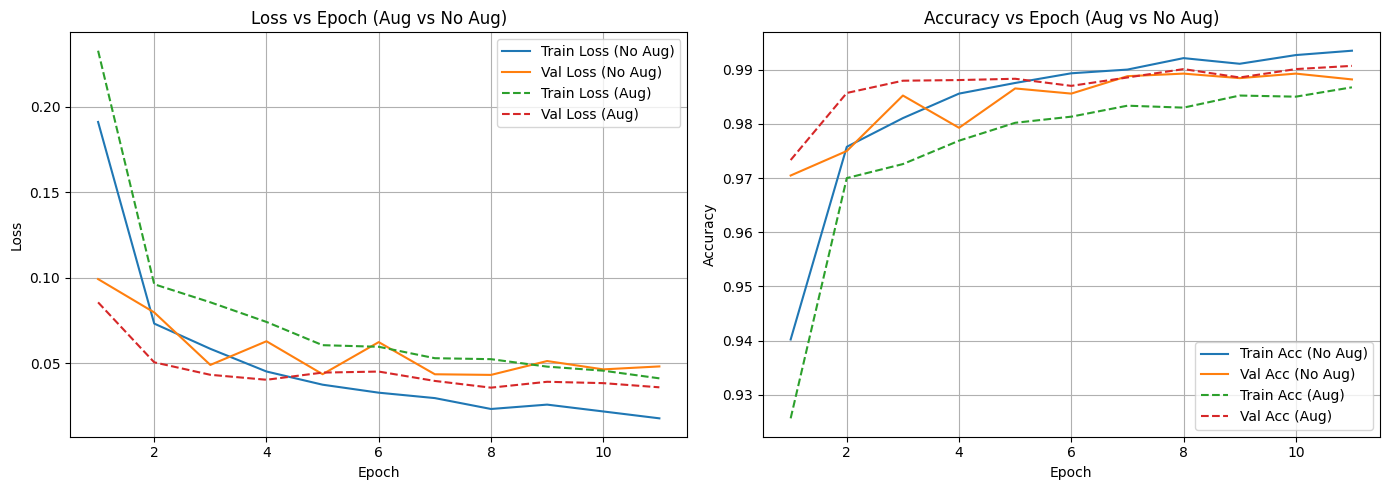

In [60]:
epochs_no_aug = range(1, len(history_no_aug["train_loss"]) + 1)
epochs_aug = range(1, len(history_aug["train_loss"]) + 1)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# --------------------
# LOSS PLOT
# --------------------
axs[0].plot(epochs_no_aug, history_no_aug["train_loss"], label="Train Loss (No Aug)")
axs[0].plot(epochs_no_aug, history_no_aug["val_loss"], label="Val Loss (No Aug)")

axs[0].plot(epochs_aug, history_aug["train_loss"], linestyle="--", label="Train Loss (Aug)")
axs[0].plot(epochs_aug, history_aug["val_loss"], linestyle="--", label="Val Loss (Aug)")

axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].set_title("Loss vs Epoch (Aug vs No Aug)")
axs[0].legend()
axs[0].grid(True)

# --------------------
# ACCURACY PLOT
# --------------------
axs[1].plot(epochs_no_aug, history_no_aug["train_acc"], label="Train Acc (No Aug)")
axs[1].plot(epochs_no_aug, history_no_aug["val_acc"], label="Val Acc (No Aug)")

axs[1].plot(epochs_aug, history_aug["train_acc"], linestyle="--", label="Train Acc (Aug)")
axs[1].plot(epochs_aug, history_aug["val_acc"], linestyle="--", label="Val Acc (Aug)")

axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy")
axs[1].set_title("Accuracy vs Epoch (Aug vs No Aug)")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

#### Comments

| Metric         | No Aug | Aug        | Winner                        |
| -------------- | ------ | ---------- | ----------------------------- |
| Val Accuracy   | 98.93% | **99.07%** | Aug ✔                         |
| Val Loss       | 0.043  | **0.036**  | Aug ✔                         |
| Train Accuracy | higher | lower      | Aug ✔ (better generalization) |


### 4. Error Analysis

In [61]:
model_aug.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model_aug(images)
        preds = outputs.argmax(dim=1).cpu()

        all_preds.append(preds)
        all_labels.append(labels)

y_val_pred = torch.cat(all_preds).numpy()
y_val_true = torch.cat(all_labels).numpy()

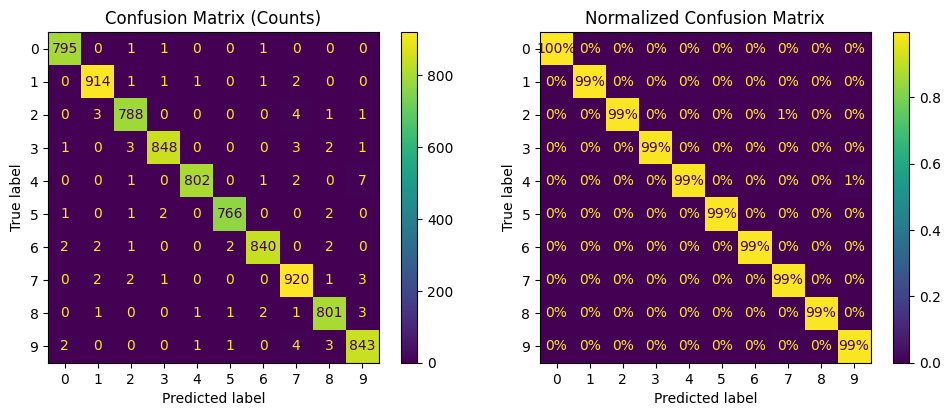

In [62]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_val_true,
    y_val_pred,
    ax=axs[0]
)
axs[0].set_title("Confusion Matrix (Counts)")

ConfusionMatrixDisplay.from_predictions(
    y_val_true,
    y_val_pred,
    normalize="true",
    values_format=".0%",
    ax=axs[1]
)
axs[1].set_title("Normalized Confusion Matrix")

plt.tight_layout()
plt.show()

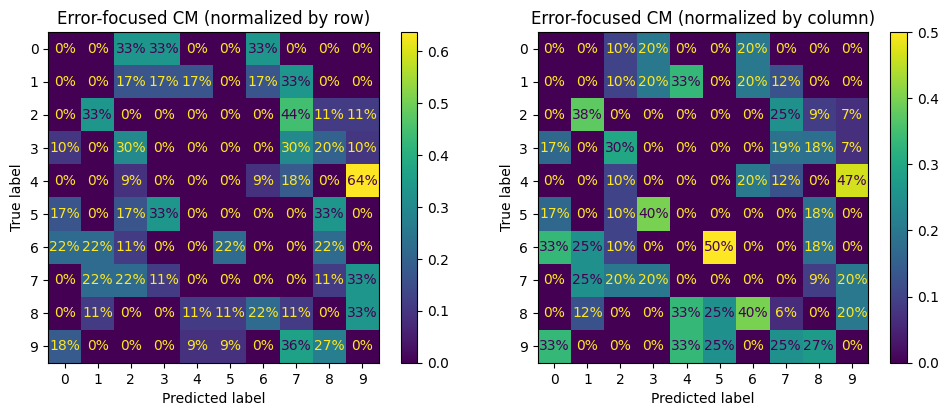

In [63]:
sample_weight = (y_val_pred != y_val_true)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_val_true,
    y_val_pred,
    ax=axs[0],
    sample_weight=sample_weight,
    normalize="true",
    values_format=".0%"
)

axs[0].set_title("Error-focused CM (normalized by row)")

ConfusionMatrixDisplay.from_predictions(
    y_val_true,
    y_val_pred,
    ax=axs[1],
    sample_weight=sample_weight,
    normalize="pred",
    values_format=".0%"
)

axs[1].set_title("Error-focused CM (normalized by column)")

plt.tight_layout()
plt.show()

This shows where mistakes happened:

* Normalized by row -  when mistaking a true digit, what digit did the model predict incorrectly?
* Normaized by column  - When the model predicted the wrong digit, what was the real digit?

#### Comments

* The model using data augmention (images randomly rotated by 15 degrees) performs slightly better based on validation loss (0.36) and validation accuracy (99.07%)
* The two largest mistakes were:
    * when the actual digit was a 4, but the model predicted a 9 (7 times)
    * when the actual digit was 2 or 9, but the model predicted a 7 (4 times each)

### 5. Hyperparameter Optimization

#### Model Tuning

In [64]:
def objective(trial):

    torch.manual_seed(42)
    np.random.seed(42)

    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)

    model_opt = MNISTModel(dropout_rate=dropout).to(device)

    optimizer = optim.Adam(model_opt.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(3):
        train_one_epoch(model_opt, train_loader_aug, optimizer, criterion, device)

        val_loss, val_acc = evaluate(model_opt, val_loader, criterion, device)

        trial.report(val_loss, epoch)

        if trial.should_prune():
            raise optuna.TrialPruned()

    return val_loss

In [65]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)

[I 2026-04-28 12:58:06,351] A new study created in memory with name: no-name-1388bf41-359d-4300-b52c-822837499585
c:\Working\kaggle-private\.venv\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
[I 2026-04-28 12:59:03,042] Trial 0 finished with value: 0.06324853155141076 and parameters: {'lr': 0.002752214058681873, 'dropout': 0.19852890379575272}. Best is trial 0 with value: 0.06324853155141076.
[I 2026-04-28 12:59:55,784] Trial 1 finished with value: 0.06407830625595082 and parameters: {'lr': 0.0004869465939695273, 'dropout': 0.1320349252220729}. Best is trial 0 with value: 0.06324853155141076.
[I 2026-04-28 13:00:51,497] Trial 2 finished with value: 0.07018074265060326 and parameters: {'lr': 0.004828381824681519, 'dropout': 0.3283422517295569}. Best is trial 0 with value: 0.06324853155141076.
[I 2026-04-28 13:01:46,468] Trial 3 finishe

In [66]:
print(study.best_params)

{'lr': 0.0002506672642907025, 'dropout': 0.28468855226241896}


#### Final Model

In [67]:
dr = study.best_params["dropout"]
lr = study.best_params["lr"]

model_final = MNISTModel(dropout_rate=dr).to(device)
optimizer = torch.optim.Adam(model_final.parameters(), lr=lr)

In [68]:
model_final_trained, history_final = train_model(model_final, 
            train_loader_aug, 
            val_loader, 
            optimizer, 
            criterion, 
            device, 
            epochs=15)

Epoch 1/15 | Train Loss 0.3180 | Val Loss 0.0747 | Train Acc 0.9072 | Val Acc 0.9798 | Counter: 0/3
Epoch 2/15 | Train Loss 0.1075 | Val Loss 0.0557 | Train Acc 0.9658 | Val Acc 0.9835 | Counter: 0/3
Epoch 3/15 | Train Loss 0.0835 | Val Loss 0.0470 | Train Acc 0.9742 | Val Acc 0.9857 | Counter: 0/3
Epoch 4/15 | Train Loss 0.0701 | Val Loss 0.0526 | Train Acc 0.9775 | Val Acc 0.9844 | Counter: 1/3
Epoch 5/15 | Train Loss 0.0605 | Val Loss 0.0475 | Train Acc 0.9813 | Val Acc 0.9863 | Counter: 2/3
Epoch 6/15 | Train Loss 0.0548 | Val Loss 0.0385 | Train Acc 0.9827 | Val Acc 0.9886 | Counter: 0/3
Epoch 7/15 | Train Loss 0.0516 | Val Loss 0.0415 | Train Acc 0.9832 | Val Acc 0.9876 | Counter: 1/3
Epoch 8/15 | Train Loss 0.0472 | Val Loss 0.0385 | Train Acc 0.9851 | Val Acc 0.9890 | Counter: 2/3
Epoch 9/15 | Train Loss 0.0446 | Val Loss 0.0341 | Train Acc 0.9850 | Val Acc 0.9904 | Counter: 0/3
Epoch 10/15 | Train Loss 0.0430 | Val Loss 0.0412 | Train Acc 0.9863 | Val Acc 0.9883 | Counter: 1/3

In [69]:
def extract_final_metrics(history, name):
    return {
        "model": name,
        "final_train_loss": history["train_loss"][-1],
        "final_val_loss": history["val_loss"][-1],
        "final_train_acc": history["train_acc"][-1],
        "final_val_acc": history["val_acc"][-1],
        "best_val_acc": max(history["val_acc"])
    }

df_compare = pd.DataFrame([
    extract_final_metrics(history_no_aug, "No Aug"),
    extract_final_metrics(history_aug, "Aug"),
    extract_final_metrics(history_final, "Aug + Optuna")
])

df_compare

,model,final_train_loss,final_val_loss,final_train_acc,final_val_acc,best_val_acc
0,No Aug,0.017806,0.048161,0.993512,0.988214,0.989286
1,Aug,0.041190,0.035948,0.986756,0.990714,0.990714
2,Aug + Optuna,0.036703,0.040376,0.988393,0.989405,0.990476


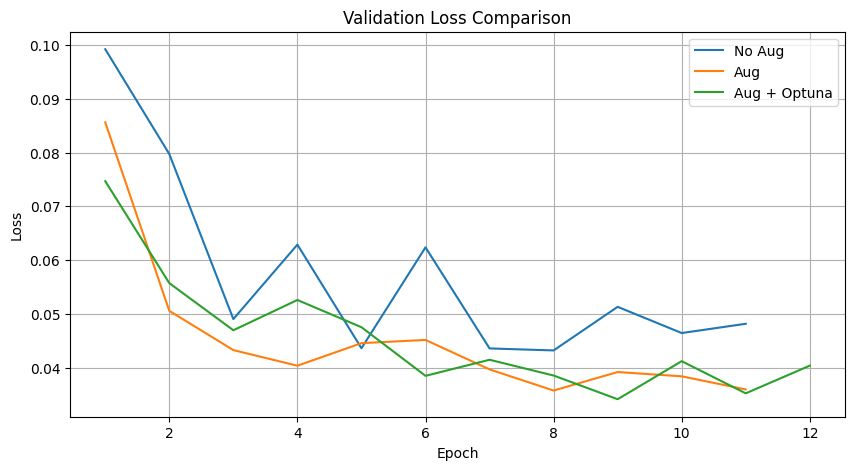

In [71]:
plt.figure(figsize=(10,5))

plt.plot(range(1, len(history_no_aug["val_loss"]) + 1),
         history_no_aug["val_loss"],
         label="No Aug")

plt.plot(range(1, len(history_aug["val_loss"]) + 1),
         history_aug["val_loss"],
         label="Aug")

plt.plot(range(1, len(history_final["val_loss"]) + 1),
         history_final["val_loss"],
         label="Aug + Optuna")

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

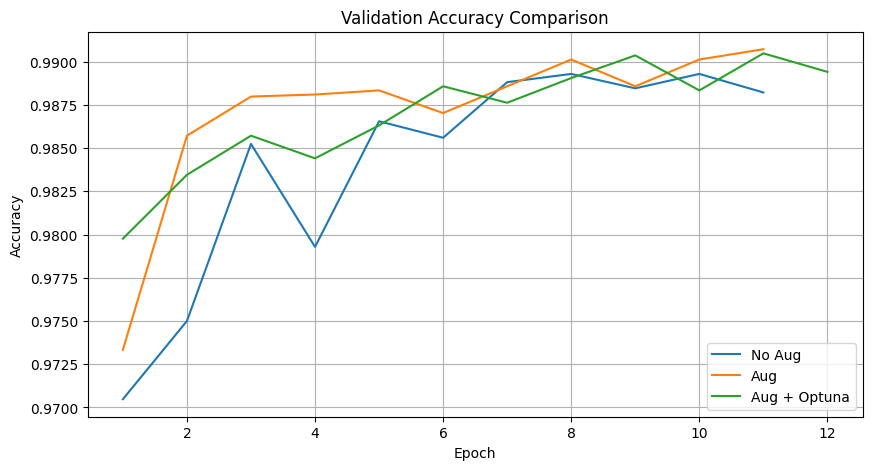

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(range(1, len(history_no_aug["val_acc"]) + 1),
         history_no_aug["val_acc"],
         label="No Aug")

plt.plot(range(1, len(history_aug["val_acc"]) + 1),
         history_aug["val_acc"],
         label="Aug")

plt.plot(range(1, len(history_final["val_acc"]) + 1),
         history_final["val_acc"],
         label="Aug + Optuna")

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### 6. Kaggle Submission

In [74]:
best_model_name = max([
    ("no_aug", history_no_aug),
    ("aug", history_aug),
    ("final", history_final)
], key=lambda x: sum(x[1]["val_acc"][-3:]) / len(x[1]["val_acc"][-3:]))[0]

best_model = {
    "no_aug": model_no_aug,
    "aug": model_aug,
    "final": model_final
}[best_model_name]

print(f"Best model based on val_acc: {best_model_name}")

Best model based on val_acc: aug


In [82]:
def predict(model, test_loader, device):
    model.eval()
    
    preds = []

    with torch.no_grad():
        for images in test_loader:
            images = images.to(device, non_blocking=True)

            outputs = model(images)
            batch_preds = outputs.argmax(dim=1).cpu()

            preds.append(batch_preds)

    return torch.cat(preds).numpy()

In [75]:
print(f'test data type: {type(test_data)}')
print(f'test_data shape: {test_data.shape}')

test data type: <class 'pandas.DataFrame'>
test_data shape: (28000, 784)


In [80]:
_, val_transform = get_transforms(aug=False)

test_dataset = MNISTDataset(test_data, pixel_columns_sorted, transform=val_transform, has_labels=False)

pin_memory = torch.cuda.is_available()

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    pin_memory=pin_memory
)

In [84]:
test_preds = predict(best_model, test_loader, device)

submission = pd.DataFrame({
    "ImageId": range(1, len(test_preds) + 1),
    "Label": test_preds
})

save_submission(submission, "submission.csv")